# ResNet50 — Experiment 1: Frozen Backbone (Baseline)
No augmentation. Frozen backbone. Direct comparison baseline against EfficientNetB0 Exp1.

In [1]:
import os, re, json
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.utils.class_weight import compute_class_weight

# ── Paths ──────────────────────────────────────────────
TRAIN_DIR = "/kaggle/input/datasets/usmanafzaal/strawberry-disease-detection-dataset/train"
VAL_DIR   = "/kaggle/input/datasets/usmanafzaal/strawberry-disease-detection-dataset/val"
TEST_DIR  = "/kaggle/input/datasets/usmanafzaal/strawberry-disease-detection-dataset/test"

# ── Class Names (confirmed from EDA) ──────────────────
CLASS_NAMES = [
    'Angular Leafspot',
    'Anthracnose Fruit Rot',
    'Blossom Blight',
    'Gray Mold',
    'Leaf Spot',
    'Powdery Mildew Fruit',
    'Powdery Mildew Leaf'
]

# ── Config ─────────────────────────────────────────────
IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
EPOCHS     = 20
LR         = 1e-3
SEED       = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)
print('Setup done.')

2026-03-11 01:44:53.692549: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773193494.097492      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773193494.204387      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773193495.179948      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773193495.179995      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773193495.179998      24 computation_placer.cc:177] computation placer alr

Setup done.


In [2]:
# ── Load Labels from JSON ───────────────────────────────
def load_split(folder):
    data = []
    for f in os.listdir(folder):
        if not f.lower().endswith('.jpg'):
            continue
        img_path  = os.path.join(folder, f)
        json_path = img_path.replace('.jpg', '.json')
        label = None
        if os.path.exists(json_path):
            try:
                with open(json_path) as jf:
                    ann = json.load(jf)
                shapes = ann.get('shapes', [])
                if shapes:
                    label = shapes[0].get('label', None)
            except:
                pass
        if not label:
            name = os.path.splitext(f)[0]
            label = re.sub(r'\d+$', '', name).strip()
        data.append([img_path, label])
    return pd.DataFrame(data, columns=['path', 'label'])

train_df = load_split(TRAIN_DIR)
val_df   = load_split(VAL_DIR)
test_df  = load_split(TEST_DIR)

label2idx   = {name: i for i, name in enumerate(CLASS_NAMES)}
NUM_CLASSES = len(CLASS_NAMES)

for df in (train_df, val_df, test_df):
    df['label_idx'] = df['label'].map(label2idx)

print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')
print(f'Classes ({NUM_CLASSES}): {CLASS_NAMES}')

Train: 1450 | Val: 307 | Test: 743
Classes (7): ['Angular Leafspot', 'Anthracnose Fruit Rot', 'Blossom Blight', 'Gray Mold', 'Leaf Spot', 'Powdery Mildew Fruit', 'Powdery Mildew Leaf']


In [3]:
# ── Class Weights ───────────────────────────────────────
weights = compute_class_weight('balanced',
                                classes=np.arange(NUM_CLASSES),
                                y=train_df['label_idx'].values)
class_weight_dict = dict(enumerate(weights))
print('Class weights:')
for name, idx in label2idx.items():
    print(f'  {name:30s}: {class_weight_dict[idx]:.4f}')

Class weights:
  Angular Leafspot              : 0.8455
  Anthracnose Fruit Rot         : 3.9835
  Blossom Blight                : 1.7554
  Gray Mold                     : 0.8155
  Leaf Spot                     : 0.5437
  Powdery Mildew Fruit          : 2.5573
  Powdery Mildew Leaf           : 0.6494


In [4]:
# ── tf.data Pipeline ────────────────────────────────────

preprocess = tf.keras.applications.resnet50.preprocess_input

def load_and_preprocess(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32)
    img = preprocess(img)   # ResNet50-specific normalization
    return img, label

def make_dataset(df, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices(
        (df['path'].values, df['label_idx'].values))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(df), seed=SEED)
    ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(train_df, shuffle=True)
val_ds   = make_dataset(val_df)
test_ds  = make_dataset(test_df)
print('Datasets ready.')

I0000 00:00:1773193560.160250      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1773193560.162773      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Datasets ready.


In [5]:
# ── Build Model: Frozen ResNet50 ────────────────────────
base_model = tf.keras.applications.ResNet50(
    include_top=False,
    weights='imagenet',
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
)
base_model.trainable = False  # Freeze all backbone layers

inputs  = layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
x       = base_model(inputs, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.BatchNormalization()(x)
x       = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model_exp1 = models.Model(inputs, outputs, name='ResNet50_Exp1')
model_exp1.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model_exp1.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "ResNet50_Exp1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 7)              │        14,343 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,610,247 (90.07 MB)

 Trainable params: 18,439 (72.03 KB)

 Non-trainable params: 23,591,808 (90.00 MB)

In [6]:
# ── Train ───────────────────────────────────────────────
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=5,
        restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=2, min_lr=1e-6, verbose=1),
]

history1 = model_exp1.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    class_weight=class_weight_dict
)

Epoch 1/20


I0000 00:00:1773193571.549149      66 service.cc:152] XLA service 0x79e7cc001f20 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773193571.549188      66 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1773193571.549194      66 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1773193573.652219      66 cuda_dnn.cc:529] Loaded cuDNN version 91002


 2/46 ━━━━━━━━━━━━━━━━━━━━ 3s 89ms/step - accuracy: 0.1719 - loss: 4.7029  

I0000 00:00:1773193579.323152      66 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


46/46 ━━━━━━━━━━━━━━━━━━━━ 31s 374ms/step - accuracy: 0.5584 - loss: 1.6379 - val_accuracy: 0.8469 - val_loss: 0.4134 - learning_rate: 0.0010
Epoch 2/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 5s 98ms/step - accuracy: 0.9243 - loss: 0.2901 - val_accuracy: 0.8795 - val_loss: 0.2842 - learning_rate: 0.0010
Epoch 3/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 5s 108ms/step - accuracy: 0.9456 - loss: 0.2235 - val_accuracy: 0.9283 - val_loss: 0.1838 - learning_rate: 0.0010
Epoch 4/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 5s 99ms/step - accuracy: 0.9703 - loss: 0.1178 - val_accuracy: 0.9414 - val_loss: 0.1582 - learning_rate: 0.0010
Epoch 5/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 5s 100ms/step - accuracy: 0.9622 - loss: 0.1244 - val_accuracy: 0.9414 - val_loss: 0.1387 - learning_rate: 0.0010
Epoch 6/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 5s 101ms/step - accuracy: 0.9745 - loss: 0.0811 - val_accuracy: 0.9609 - val_loss: 0.1166 - learning_rate: 0.0010
Epoch 7/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 5s 98ms/step - accuracy: 0.9871 - loss: 0.0552 - val_accuracy:

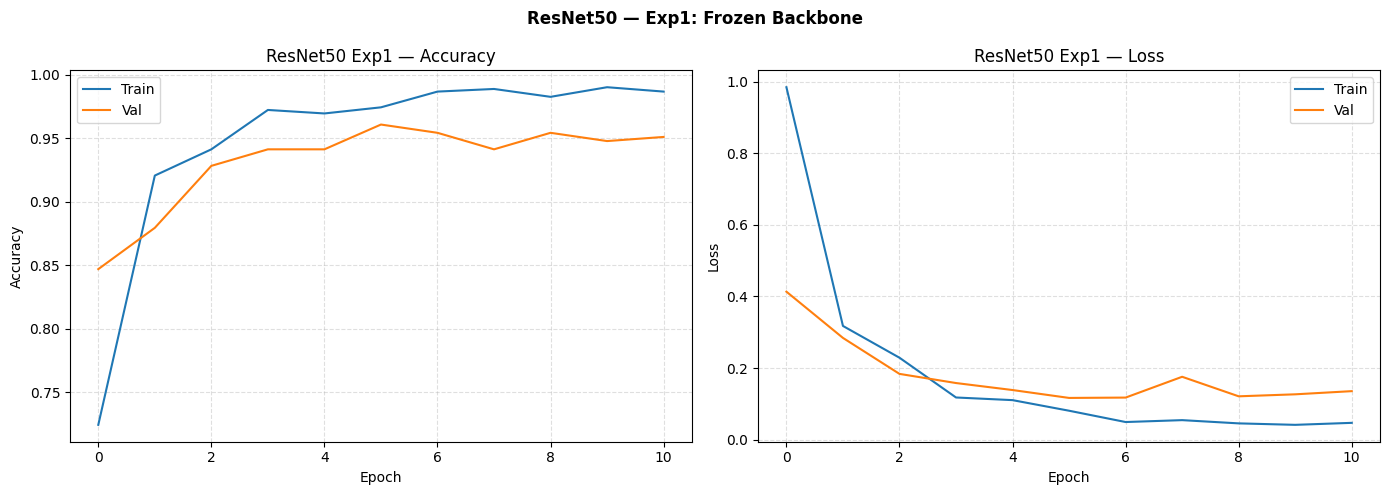

In [7]:
# ── Training Curves ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history1.history['accuracy'],     label='Train')
axes[0].plot(history1.history['val_accuracy'], label='Val')
axes[0].set_title('ResNet50 Exp1 — Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(linestyle='--', alpha=0.4)

axes[1].plot(history1.history['loss'],     label='Train')
axes[1].plot(history1.history['val_loss'], label='Val')
axes[1].set_title('ResNet50 Exp1 — Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(linestyle='--', alpha=0.4)

plt.suptitle('ResNet50 — Exp1: Frozen Backbone', fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/resnet_exp1_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# ── Evaluate on Test Set ────────────────────────────────
test_loss, test_acc = model_exp1.evaluate(test_ds, verbose=0)
print(f'[ResNet50 Exp1] Test Loss    : {test_loss:.4f}')
print(f'[ResNet50 Exp1] Test Accuracy: {test_acc:.4f}')

y_true = np.concatenate([y for _, y in test_ds], axis=0)
y_prob = model_exp1.predict(test_ds)
y_pred = np.argmax(y_prob, axis=1)

print('\n[ResNet50 Exp1] Classification Report:')
print(classification_report(y_true, y_pred,
      target_names=CLASS_NAMES, digits=4, zero_division=0))

[ResNet50 Exp1] Test Loss    : 0.4120
[ResNet50 Exp1] Test Accuracy: 0.8789
24/24 ━━━━━━━━━━━━━━━━━━━━ 9s 237ms/step

[ResNet50 Exp1] Classification Report:
                       precision    recall  f1-score   support

     Angular Leafspot     0.8650    0.9592    0.9097       147
Anthracnose Fruit Rot     0.6000    0.7059    0.6486        34
       Blossom Blight     0.9688    1.0000    0.9841        62
            Gray Mold     0.8519    0.9517    0.8990       145
            Leaf Spot     0.9831    0.7205    0.8315       161
 Powdery Mildew Fruit     0.5952    0.5814    0.5882        43
  Powdery Mildew Leaf     0.9545    0.9735    0.9639       151

             accuracy                         0.8789       743
            macro avg     0.8312    0.8417    0.8322       743
         weighted avg     0.8871    0.8789    0.8774       743



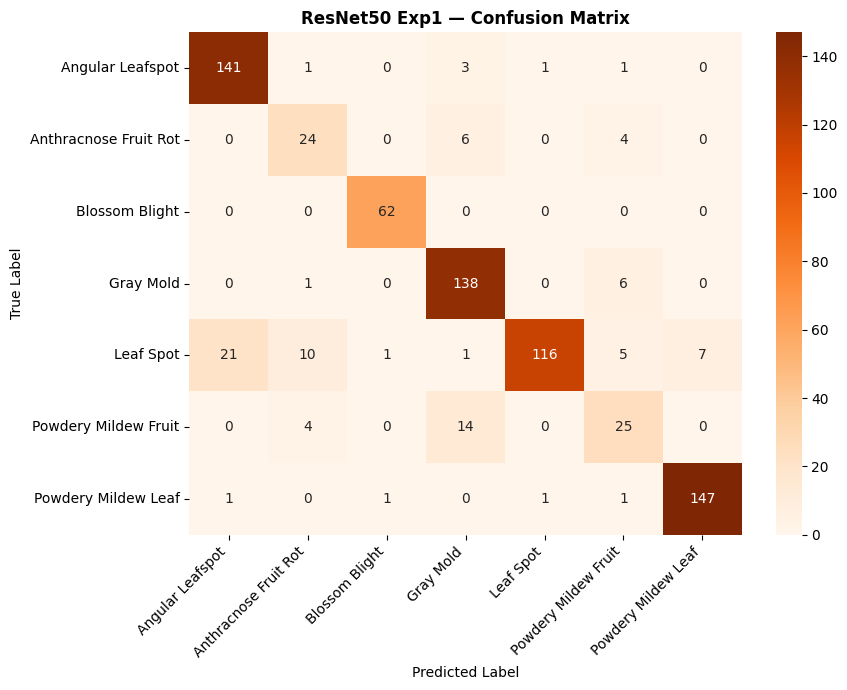

In [9]:
# ── Confusion Matrix ────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('ResNet50 Exp1 — Confusion Matrix', fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('/kaggle/working/resnet_exp1_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# ── Save Model + Results CSV ────────────────────────────
model_exp1.save('/kaggle/working/resnet_exp1.keras')

exp1_results = {
    'experiment' : 'Exp1 - Frozen',
    'model'      : 'ResNet50',
    'test_acc'   : round(float(test_acc), 4),
    'test_loss'  : round(float(test_loss), 4),
    'f1_weighted': round(f1_score(y_true, y_pred, average='weighted', zero_division=0), 4),
    'precision'  : round(precision_score(y_true, y_pred, average='weighted', zero_division=0), 4),
    'recall'     : round(recall_score(y_true, y_pred, average='weighted', zero_division=0), 4),
}
pd.DataFrame([exp1_results]).to_csv('/kaggle/working/resnet_exp1_results.csv', index=False)
print('Model and results saved!')
print(exp1_results)

Model and results saved!
{'experiment': 'Exp1 - Frozen', 'model': 'ResNet50', 'test_acc': 0.8789, 'test_loss': 0.412, 'f1_weighted': 0.8774, 'precision': 0.8871, 'recall': 0.8789}
